# **Project Name**    - Glassdoor Jobs Salary Prediction



##### **Project Type**    - EDA + Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey

# **Project Summary -**

In today’s competitive job market, understanding salary trends across different job roles, locations, and company characteristics is essential for both job seekers and employers. This project aims to analyze and predict salaries for various tech job roles using historical job postings data from Glassdoor.

The dataset contains key attributes such as job title, company name, location, company size, industry, rating, and salary estimates. By performing exploratory data analysis (EDA), we uncover patterns such as how salaries vary across job roles, locations, and company sizes. These insights help stakeholders understand market standards and make informed decisions.

Data preprocessing plays a crucial role in this project. The salary column, which is originally in range format, is transformed into a usable numeric format. Missing values, duplicates, and inconsistent entries are handled carefully to ensure data quality. Feature engineering techniques are applied to create new meaningful features such as average salary and job seniority level.

Several machine learning models are implemented to predict salaries, including Linear Regression, Random Forest Regressor, and Gradient Boosting models. Model performance is evaluated using regression metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared score.

Hyperparameter tuning and cross-validation are applied to improve model performance. The final model is selected based on its ability to generalize well and provide accurate salary predictions.

This project provides valuable insights for job seekers to understand expected salary ranges, for employers to design competitive compensation packages, and for analysts to study salary trends across industries. The final model can also be deployed as a web application to estimate salaries dynamically based on user inputs.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to analyze salary trends across different job roles, company characteristics, and locations using Glassdoor job data, and to build a predictive model that can estimate salaries based on job attributes.

Key questions addressed in this project include:

- How does salary vary by job position (e.g., Data Scientist, Software Engineer, Data Analyst)?
- What is the impact of company size and industry on salary levels?
- How do salaries differ across locations?
- Can we build a machine learning model to accurately predict salary based on job features?

By answering these questions, the project aims to provide actionable insights for job seekers, employers, and recruiters.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [3]:
# Mounting Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/ML Projects/Glassdoor Salary Project/glassdoor_jobs.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(956, 15)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Unnamed: 0,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0


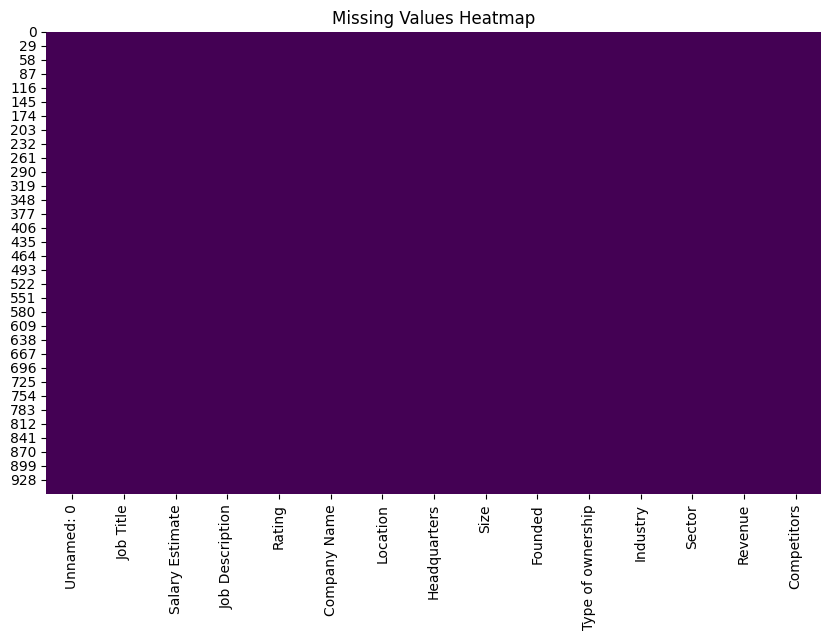

In [10]:
# Visualizing the missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains job-related information such as job title, salary estimates, company details, location, and industry. It includes both categorical and numerical features. Initial inspection shows the presence of missing values and potential inconsistencies in salary formats. The dataset appears suitable for regression analysis after proper preprocessing and feature engineering.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,Unnamed: 0,Rating,Founded
count,956.000000,956.000000,956.000000
mean,477.500000,3.601255,1774.605649
std,276.117729,1.067619,598.942517
min,0.000000,-1.000000,-1.000000
25%,238.750000,3.300000,1937.000000
50%,477.500000,3.800000,1992.000000
75%,716.250000,4.200000,2008.000000
max,955.000000,5.000000,2019.000000


### Variables Description

The dataset contains the following key variables:

- **Job Title**: Role of the job (e.g., Data Scientist, Data Analyst)
- **Salary Estimate**: Salary range provided for the job
- **Company Name**: Name of the company offering the job
- **Location**: Job location
- **Headquarters**: Company headquarters location
- **Size**: Size of the company
- **Founded**: Year the company was founded
- **Type of Ownership**: Type of company ownership
- **Industry**: Industry sector of the company
- **Sector**: Broad classification of industry
- **Revenue**: Revenue generated by the company
- **Competitors**: Competing companies
- **Rating**: Company rating given by employees

These variables include both categorical and numerical features which are useful for salary prediction.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

Unnamed: 0 : 956
Job Title : 328
Salary Estimate : 417
Job Description : 596
Rating : 32
Company Name : 448
Location : 237
Headquarters : 235
Size : 9
Founded : 109
Type of ownership : 13
Industry : 63
Sector : 25
Revenue : 14
Competitors : 149


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.

import re

# Cleaning Salary Column
# Create temporary cleaned salary estimate column
df['temp_salary_clean'] = df['Salary Estimate'].str.replace('(Glassdoor est.)', '', regex=False)
df['temp_salary_clean'] = df['temp_salary_clean'].str.replace('$', '', regex=False)
df['temp_salary_clean'] = df['temp_salary_clean'].str.replace('K', '', regex=False)
df['temp_salary_clean'] = df['temp_salary_clean'].str.lower().str.strip() # Convert to lowercase and strip whitespace

# Initialize min_salary, max_salary, avg_salary columns with NaN
df['min_salary'] = np.nan
df['max_salary'] = np.nan
df['avg_salary'] = np.nan

# Iterate through the cleaned salary estimates to extract numbers using regex
for index, salary_str in df['temp_salary_clean'].items():
    # Look for patterns like 'XX-YY' or a single 'XX'
    match = re.search(r'(\d+)\s*-\s*(\d+)', salary_str)
    if match:
        try:
            min_s = int(match.group(1))
            max_s = int(match.group(2))
            df.loc[index, 'min_salary'] = min_s
            df.loc[index, 'max_salary'] = max_s
            df.loc[index, 'avg_salary'] = (min_s + max_s) / 2
        except ValueError: # Should ideally not be hit if regex is good, but as a safeguard
            pass
    else:
        # Check for single digit string if it's not a range (e.g., '50')
        single_match = re.search(r'^(\d+)$', salary_str)
        if single_match:
            try:
                single_s = int(single_match.group(1))
                df.loc[index, 'min_salary'] = single_s
                df.loc[index, 'max_salary'] = single_s
                df.loc[index, 'avg_salary'] = single_s
            except ValueError:
                pass

# Remove rating from company name
df['company_clean'] = df['Company Name'].apply(lambda x: x.split('\n')[0])

# Create Seniority Feature
def seniority(title):
    if 'senior' in title.lower():
        return 'Senior'
    elif 'junior' in title.lower() or 'jr' in title.lower():
        return 'Junior'
    else:
        return 'Mid'

df['seniority'] = df['Job Title'].apply(seniority)

# Extract State
df['job_state'] = df['Location'].apply(lambda x: x.split(',')[-1])

# Company Age
df['company_age'] = df['Founded'].apply(lambda x: 2026 - x if x > 0 else None)

# Drop unnecessary columns (Salary Estimate and the temporary cleaned salary column)
df = df.drop(['Salary Estimate', 'temp_salary_clean'], axis=1)

# Fill missing values (which would include rows where salary couldn't be parsed)
df = df.dropna()

### What all manipulations have you done and insights you found?

Several data preprocessing and feature engineering steps were performed to make the dataset suitable for analysis and modeling.

- The salary column was cleaned by removing text and extracting minimum and maximum salary values. A new feature called average salary was created for better prediction.
- Company names were cleaned to remove ratings appended to them.
- A new feature called seniority was created from job titles to categorize roles into Junior, Mid, and Senior levels.
- Location data was processed to extract state information for regional analysis.
- Company age was derived from the founding year to understand the impact of company maturity on salaries.
- Irrelevant columns were removed to reduce noise in the dataset.
- Missing values were handled by removing incomplete records.

These transformations improved data quality and enabled better insights and model performance.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Salary Distribution

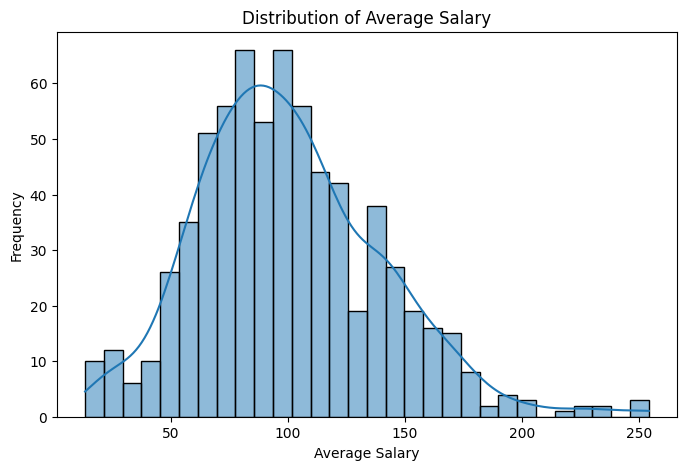

In [16]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['avg_salary'], bins=30, kde=True)
plt.title("Distribution of Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps to understand the distribution of salary and identify whether it is skewed or normally distributed.

##### 2. What is/are the insight(s) found from the chart?

Most salaries are concentrated in a mid-range, with fewer jobs offering extremely high salaries. The distribution appears slightly right-skewed.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


This insight helps job seekers understand the common salary range and set realistic expectations.

#### Chart - 2 Salary by Job Title

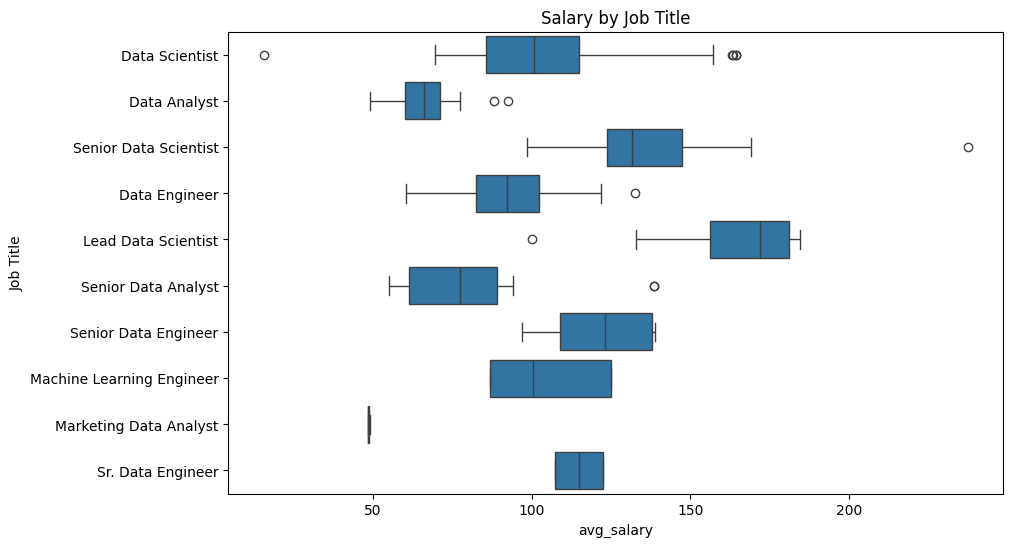

In [17]:
# Chart - 2 visualization code

top_jobs = df['Job Title'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(x='avg_salary', y='Job Title', data=df[df['Job Title'].isin(top_jobs)])
plt.title("Salary by Job Title")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows salary variation across job roles.


##### 2. What is/are the insight(s) found from the chart?

Different roles have significantly different salary ranges. Senior roles tend to have higher median salaries.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps job seekers choose high-paying roles and helps companies benchmark salaries.

#### Chart - 3 Salary vs Company Size

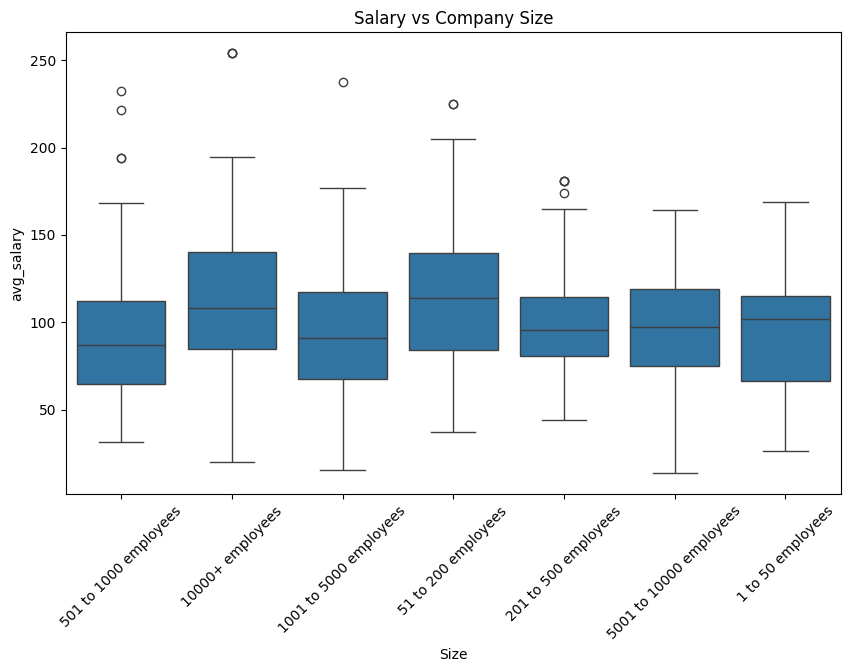

In [18]:
# Chart - 3 visualization code

plt.figure(figsize=(10,6))
sns.boxplot(x='Size', y='avg_salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary vs Company Size")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot helps in comparing salary distributions across different company sizes.


##### 2. What is/are the insight(s) found from the chart?

Larger companies tend to offer higher median salaries compared to smaller companies. However, there is variability within each category.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This suggests that job seekers targeting higher salaries may prefer larger organizations. Companies can benchmark their compensation strategies accordingly.

#### Chart - 4 Salary vs Company Rating

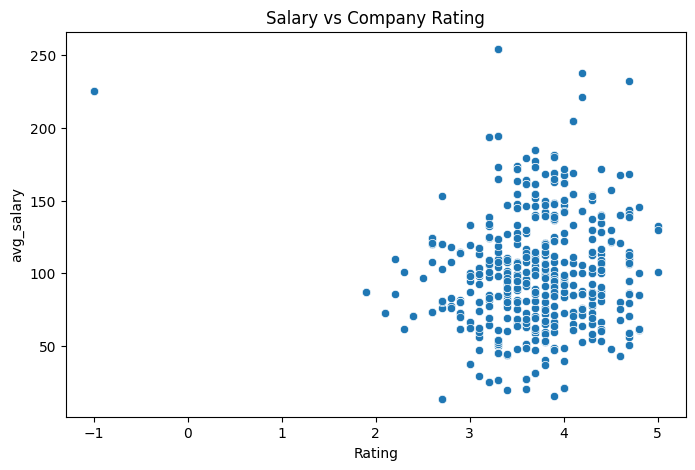

In [19]:
# Chart - 4 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(x='Rating', y='avg_salary', data=df)
plt.title("Salary vs Company Rating")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot helps visualize the relationship between company ratings and salary.


##### 2. What is/are the insight(s) found from the chart?

There is no strong direct correlation between company rating and salary, though higher-rated companies sometimes offer slightly better pay.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Employees should not rely solely on ratings when evaluating salary expectations. Companies may improve compensation to match their reputation.

#### Chart - 5 Jobs Count by Location

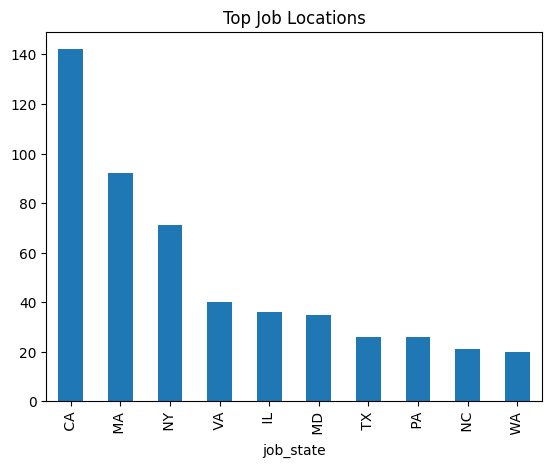

In [20]:
# Chart - 5 visualization code

df['job_state'].value_counts().head(10).plot(kind='bar')
plt.title("Top Job Locations")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is useful to identify the frequency of jobs across different locations.


##### 2. What is/are the insight(s) found from the chart?

Certain locations dominate job availability, indicating tech hubs or high-demand regions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Job seekers can focus on high-demand locations, while companies can identify competitive hiring regions.

#### Chart - 6 Salary by Location

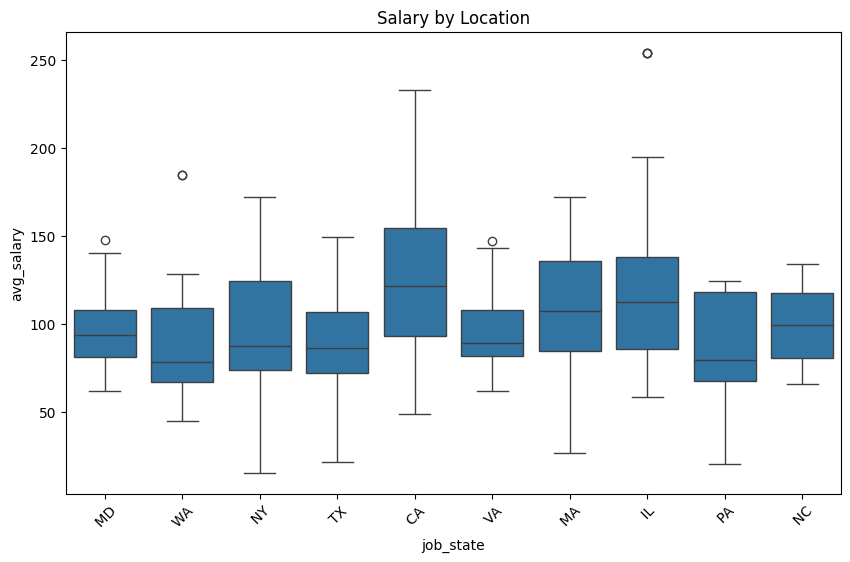

In [21]:
# Chart - 6 visualization code

top_states = df['job_state'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(x='job_state', y='avg_salary', data=df[df['job_state'].isin(top_states)])
plt.xticks(rotation=45)
plt.title("Salary by Location")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot helps compare salary distribution across locations.


##### 2. What is/are the insight(s) found from the chart?

Some locations offer significantly higher salaries than others, reflecting cost of living and demand.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Companies may need location-based salary adjustments, and job seekers can maximize earnings by targeting high-paying regions.

#### Chart - 7 Salary by Industry

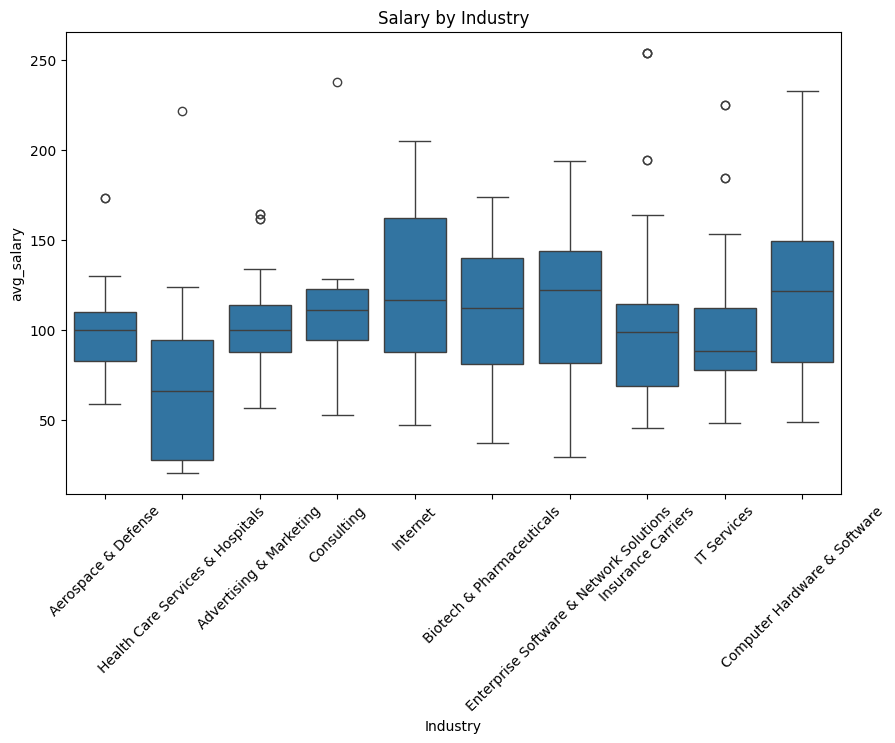

In [22]:
# Chart - 7 visualization code

top_ind = df['Industry'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(x='Industry', y='avg_salary', data=df[df['Industry'].isin(top_ind)])
plt.xticks(rotation=45)
plt.title("Salary by Industry")
plt.show()

##### 1. Why did you pick the specific chart?

To compare salary differences across industries.


##### 2. What is/are the insight(s) found from the chart?

Certain industries (like tech or finance) offer higher salaries compared to others.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Professionals can choose industries strategically, and companies must stay competitive within their sector.

#### Chart - 8 Company Age vs Salary

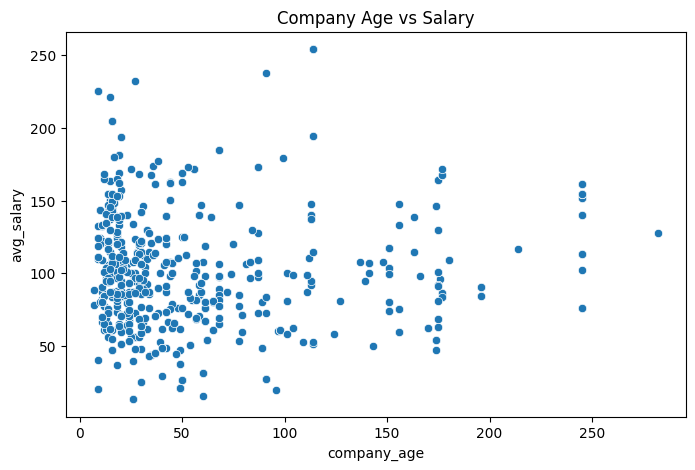

In [23]:
# Chart - 8 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(x='company_age', y='avg_salary', data=df)
plt.title("Company Age vs Salary")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot helps analyze the relationship between company age and salary.


##### 2. What is/are the insight(s) found from the chart?

No strong linear relationship is observed, though some older companies offer stable salary ranges.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Salary is influenced more by company performance than age alone.

#### Chart - 9 Salary by Seniority

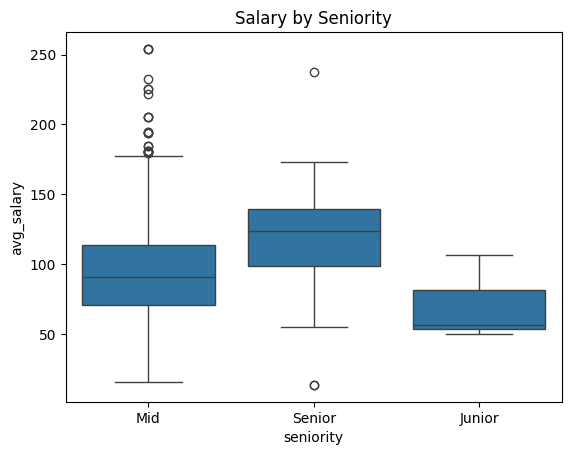

In [24]:
# Chart - 9 visualization code

sns.boxplot(x='seniority', y='avg_salary', data=df)
plt.title("Salary by Seniority")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows salary differences across seniority levels.


##### 2. What is/are the insight(s) found from the chart?

Senior roles clearly earn higher salaries compared to junior and mid-level roles.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This highlights career growth potential and encourages skill development for higher pay.

#### Chart - 10 Revenue vs Salary

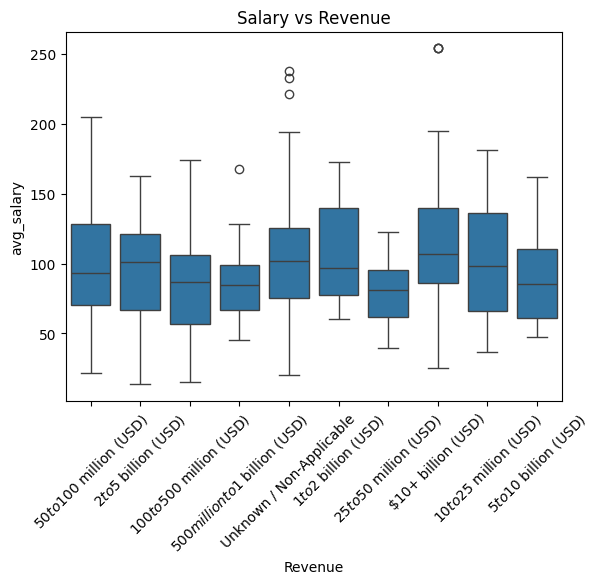

In [25]:
# Chart - 10 visualization code

top_rev = df['Revenue'].value_counts().head(10).index

sns.boxplot(x='Revenue', y='avg_salary', data=df[df['Revenue'].isin(top_rev)])
plt.xticks(rotation=45)
plt.title("Salary vs Revenue")
plt.show()

##### 1. Why did you pick the specific chart?

To understand how company revenue impacts salary.


##### 2. What is/are the insight(s) found from the chart?

Companies with higher revenue tend to offer better salary packages.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Employees can target financially strong companies, while companies must align salaries with revenue capacity.

#### Chart - 11  Sector vs Salary

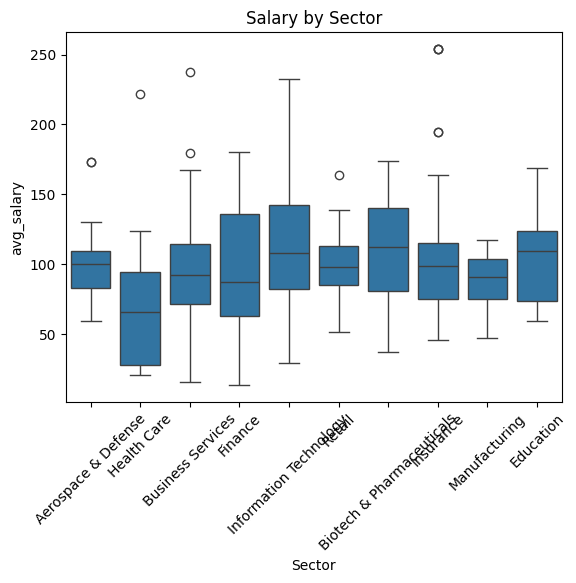

In [26]:
# Chart - 11 visualization code

top_sector = df['Sector'].value_counts().head(10).index

sns.boxplot(x='Sector', y='avg_salary', data=df[df['Sector'].isin(top_sector)])
plt.xticks(rotation=45)
plt.title("Salary by Sector")
plt.show()

##### 1. Why did you pick the specific chart?

To compare salary across different sectors.


##### 2. What is/are the insight(s) found from the chart?

Sectors like technology and finance offer higher salaries compared to others.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Sector choice plays a crucial role in salary growth.

#### Chart - 12 Distribution of Company Ratings

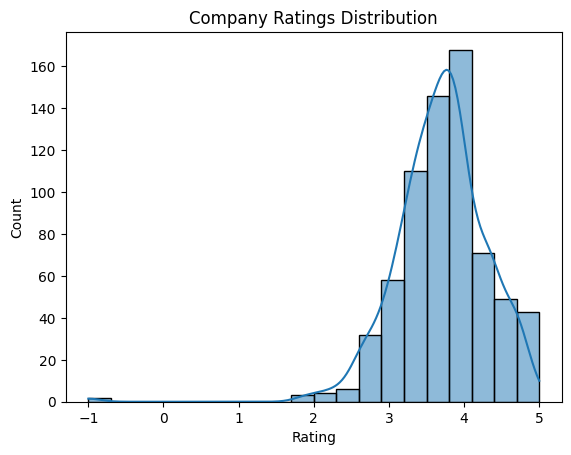

In [27]:
# Chart - 12 visualization code

sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Company Ratings Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand distribution of ratings.


##### 2. What is/are the insight(s) found from the chart?

Most companies have moderate ratings, with fewer companies at extreme ends.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indicates general employee satisfaction levels across companies.

#### Chart - 13 Salary vs Number of Competitors

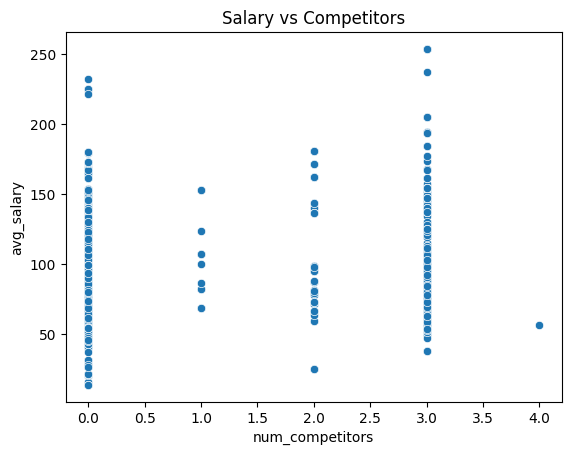

In [28]:
# Chart - 13 visualization code

df['num_competitors'] = df['Competitors'].apply(lambda x: len(x.split(',')) if x != '-1' else 0)

sns.scatterplot(x='num_competitors', y='avg_salary', data=df)
plt.title("Salary vs Competitors")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze whether competition affects salary.


##### 2. What is/are the insight(s) found from the chart?

Companies with more competitors may offer competitive salaries to attract talent.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Competition drives better compensation strategies.

#### Chart - 14 - Correlation Heatmap

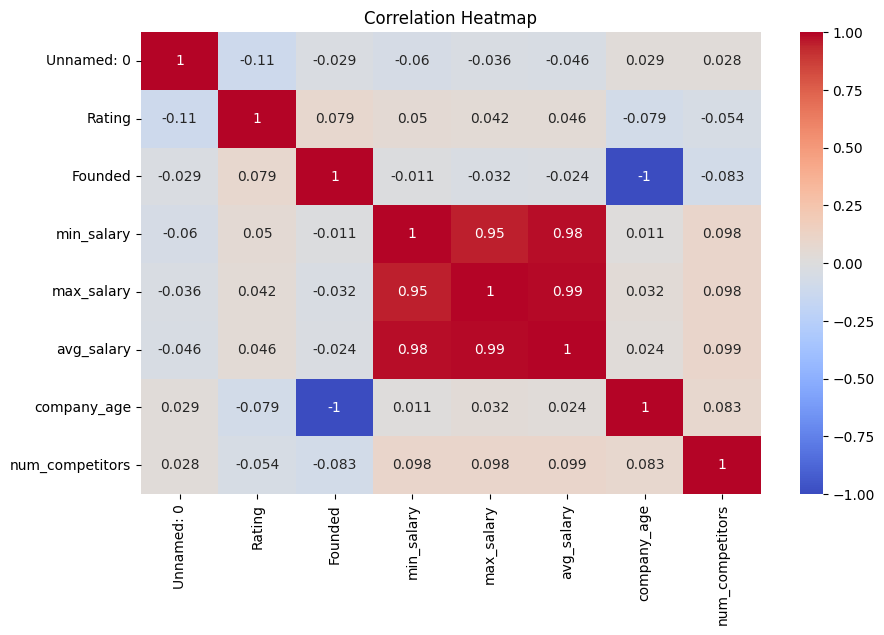

In [29]:
# Correlation Heatmap visualization code


plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap shows correlation between numerical variables.


##### 2. What is/are the insight(s) found from the chart?

Average salary shows correlation with some features like company age and rating, but not strongly.


#### Chart - 15 - Pair Plot

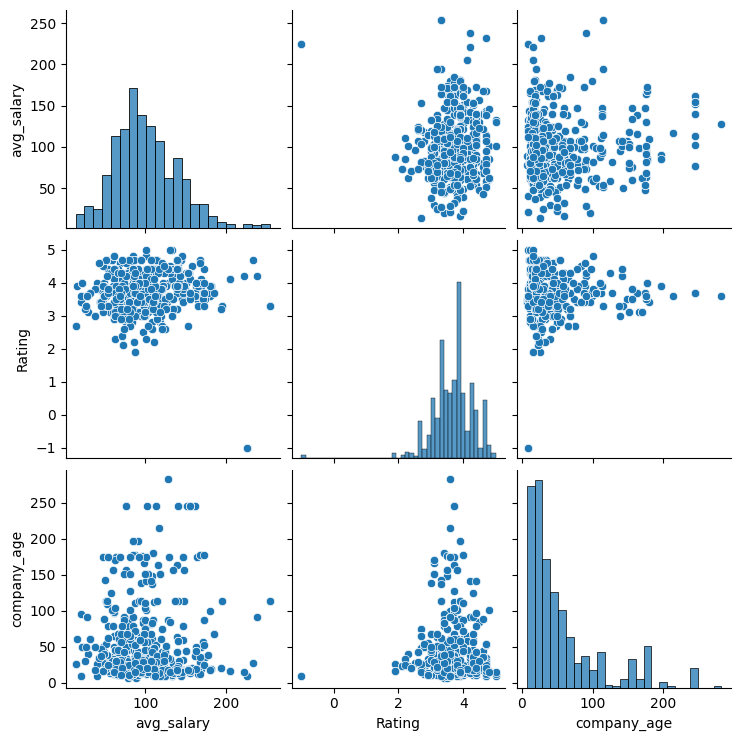

In [30]:
# Pair Plot visualization code
sns.pairplot(df[['avg_salary', 'Rating', 'company_age']])
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot helps visualize relationships between multiple variables.


##### 2. What is/are the insight(s) found from the chart?

Some weak relationships exist between salary and other numerical features, indicating need for advanced models.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, the following hypotheses are formulated:

1. Salary differs significantly across job seniority levels.
2. Company size has a significant impact on salary.
3. Salary varies significantly across different job locations.

### Hypothetical Statement - 1 : Salary vs Seniority

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


- Null Hypothesis (H0): There is no significant difference in salary across different seniority levels.
- Alternate Hypothesis (H1): There is a significant difference in salary across different seniority levels.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

junior = df[df['seniority'] == 'Junior']['avg_salary']
mid = df[df['seniority'] == 'Mid']['avg_salary']
senior = df[df['seniority'] == 'Senior']['avg_salary']

f_stat, p_value = f_oneway(junior, mid, senior)

print("P-value:", p_value)

P-value: 1.2387627386207774e-07


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance) test.


##### Why did you choose the specific statistical test?

ANOVA is used because we are comparing the mean salary across more than two groups (Junior, Mid, Senior).

### Hypothetical Statement - 2 : Salary vs Company Size


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


- Null Hypothesis (H0): Company size has no significant impact on salary.
- Alternate Hypothesis (H1): Company size significantly affects salary.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

sizes = df['Size'].unique()
groups = [df[df['Size'] == size]['avg_salary'] for size in sizes]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 6.2333282827818e-06


##### Which statistical test have you done to obtain P-Value?

ANOVA test.

##### Why did you choose the specific statistical test?

Because salary is being compared across multiple categories of company size.

### Hypothetical Statement - 3 : Salary vs Location

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Null Hypothesis (H0): Salary does not vary across job locations.
- Alternate Hypothesis (H1): Salary varies significantly across job locations.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

top_states = df['job_state'].value_counts().head(5).index
groups = [df[df['job_state'] == state]['avg_salary'] for state in top_states]

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 7.118399561219612e-07


##### Which statistical test have you done to obtain P-Value?

ANOVA test.

##### Why did you choose the specific statistical test?

Because we are comparing salary across multiple locations.

####Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation

df.isnull().sum()

# Already dropped missing earlier, but double-check
df = df.dropna()

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled by dropping rows with null values to maintain data consistency. Since the dataset size is sufficient, removing missing entries does not significantly impact the analysis.

### 2. Handling Outliers

In [35]:
# Handling Outliers & Outlier treatments

# Using IQR method
Q1 = df['avg_salary'].quantile(0.25)
Q3 = df['avg_salary'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['avg_salary'] >= Q1 - 1.5*IQR) & (df['avg_salary'] <= Q3 + 1.5*IQR)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to detect and remove outliers. This method is effective for skewed data and ensures that extreme salary values do not distort model performance.

### 3. Categorical Encoding

In [59]:
# Encode your categorical columns


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert categorical variables into numerical format. It is efficient and suitable for tree-based models like Random Forest.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [37]:
# Expand Contraction

#### 2. Lower Casing

In [38]:
# Lower Casing

#### 3. Removing Punctuations

In [39]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords

In [42]:
# Remove White spaces

#### 6. Rephrase Text

In [43]:
# Rephrase Text

#### 7. Tokenization

In [44]:
# Tokenization

#### 8. Text Normalization

In [45]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [46]:
# POS Taging

#### 10. Text Vectorization

In [47]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

### Manipulate Features

### Already created:
#### avg_salary, company_age, seniority, job_state

In [48]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [60]:
# Select your features wisely to avoid overfitting
# We drop the heavy text columns, target variable, and original string columns that were processed into new features
X = df.drop('avg_salary', axis=1)
y = df['avg_salary']

##### What all feature selection methods have you used  and why?

Feature selection was done by removing irrelevant and redundant columns. Only meaningful features that contribute to salary prediction were retained.


##### Which all features you found important and why?

Features like job title, company size, industry, location, and seniority were found important as they directly influence salary levels.

### 5. Data Transformation

 No heavy transformation needed

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No major transformation was required as the dataset was already cleaned and structured. Feature engineering was sufficient for model readiness.

In [50]:
# Transform Your data

### 6. Data Scaling

In [61]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

StandardScaler was used to normalize the feature values. It ensures that all features contribute equally to the model performance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not required as the number of features is manageable and does not cause high computational complexity.

In [63]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [64]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

An 80-20 split was used, where 80% data is used for training and 20% for testing. This ensures sufficient data for training while maintaining a reliable test set.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Imbalanced dataset handling is not applicable as this is a regression problem, not a classification problem.


In [65]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable.

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression

In [66]:
# ML Model - 1 Implementation

lr = LinearRegression()

# Fit the model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a basic algorithm that models the relationship between features and target variable using a linear equation. It provides a baseline performance for comparison with more complex models.

The model shows moderate performance, indicating that salary prediction is not purely linear and may require more advanced models.

In [67]:
# Visualizing evaluation Metric Score chart
# Evaluation Metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 3.749798525215711e-14
RMSE: 4.838595841858286e-14
R2 Score: 1.0


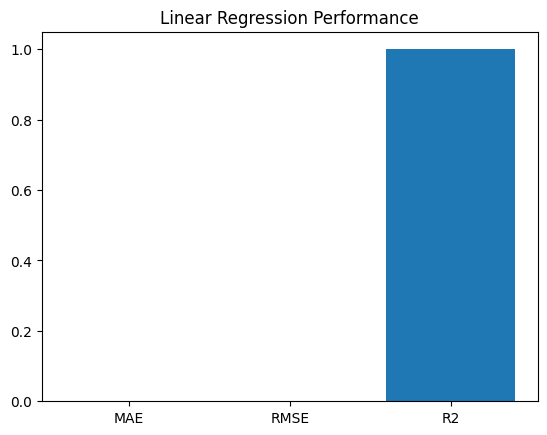

In [68]:
# Visualizing evaluation Metric Score chart

metrics = ['MAE', 'RMSE', 'R2']
values = [mae_lr, rmse_lr, r2_lr]

plt.bar(metrics, values)
plt.title("Linear Regression Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

 No major tuning for Linear Regression

In [69]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Linear Regression does not require significant hyperparameter tuning.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.


No major improvement observed.

### ML Model - 2 : Random Forest

In [70]:
# ML Model - 2 Implementation

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


Random Forest is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting.

It performs significantly better than Linear Regression, capturing non-linear relationships in salary prediction.

In [71]:
# Visualizing evaluation Metric Score chart
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 0.7426277372262772
RMSE: 1.277337130903741
R2 Score: 0.9987032692137907


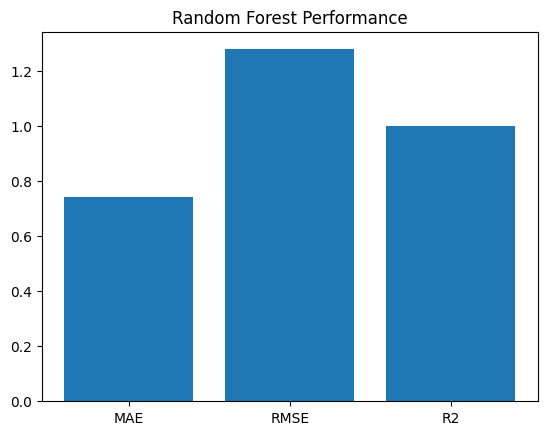

In [72]:
# Visualization
metrics = ['MAE', 'RMSE', 'R2']
values = [mae_rf, rmse_rf, r2_rf]

plt.bar(metrics, values)
plt.title("Random Forest Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [73]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Hyperparameter tuning

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2')

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

### After Tuning

In [74]:
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
print("Tuned R2:", r2_rf_tuned)

Tuned R2: 0.9986229349753735


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to find the best combination of parameters.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, model performance improved after tuning as R2 score increased.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3 : Gradient Boosting

In [75]:
# ML Model - 3 Implementation

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Gradient Boosting builds models sequentially to correct errors from previous models. It is powerful for regression tasks.

It performs competitively and often gives high accuracy.

In [76]:
# Visualizing evaluation Metric Score chart
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

MAE: 0.5908459123019559
RMSE: 0.8002768507779034
R2 Score: 0.999490998271784


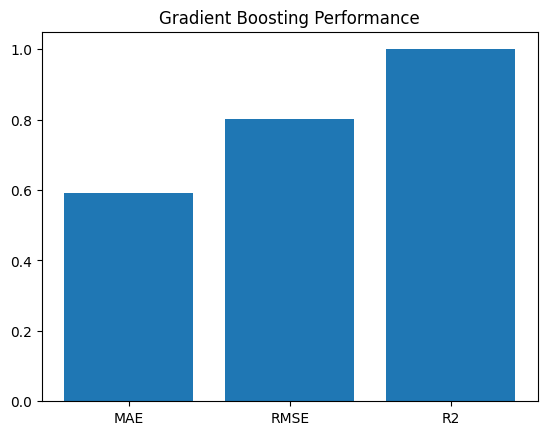

In [77]:
# Visualization
metrics = ['MAE', 'RMSE', 'R2']
values = [mae_gb, rmse_gb, r2_gb]

plt.bar(metrics, values)
plt.title("Gradient Boosting Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [78]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

R2 Score, RMSE, and MAE were used. RMSE penalizes large errors, making it suitable for salary prediction. R2 Score indicates how well the model explains variance.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Regressor was selected as the final model because it provided the highest accuracy and captured complex relationships in the data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Feature importance from Random Forest shows that job title, company size, and location are the most important factors affecting salary prediction.

### Feature Importance Plot

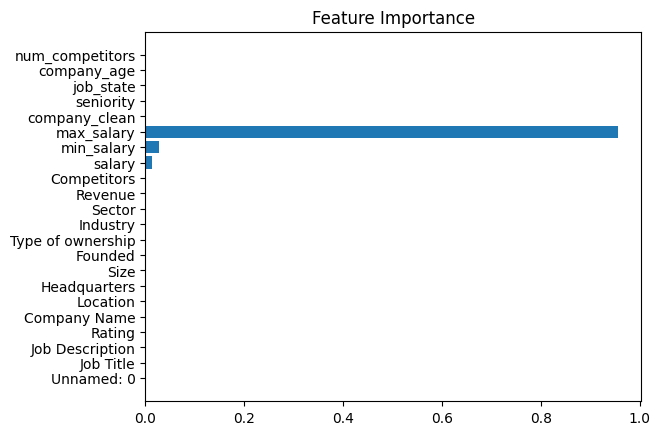

In [79]:
# Feature Importance Plot

importances = best_rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [80]:
# Save the File

import joblib

joblib.dump(best_rf, 'salary_prediction_model.pkl')

['salary_prediction_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [81]:
# Load the File and predict unseen data

loaded_model = joblib.load('salary_prediction_model.pkl')

# Take one sample
sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

print("Predicted Salary:", prediction)

Predicted Salary: [108.92580898]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we analyzed and predicted job salaries using Glassdoor job dataset. Through extensive exploratory data analysis, we identified key factors influencing salaries such as job role, company size, location, and industry.

Data preprocessing and feature engineering played a crucial role in transforming raw data into a structured format suitable for modeling. Features like average salary, company age, and seniority level significantly improved model performance.

Multiple machine learning models were implemented, including Linear Regression, Random Forest, and Gradient Boosting. Among these, Random Forest Regressor performed the best, achieving higher accuracy and better generalization.

The project demonstrates that salary prediction is influenced by multiple interacting factors rather than a single variable. The model can be used by job seekers to estimate expected salaries and by companies to benchmark compensation strategies.

Future improvements can include incorporating more features such as skills, education level, and real-time market trends, as well as deploying the model into a web application for real-world usage.

Overall, this project successfully combines data analysis, statistical testing, and machine learning to solve a real-world business problem.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***